In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

In [5]:
# =========================
# 1. LOAD DATA
# =========================

df = pd.read_csv(
    "../notebook/rfm.csv"
)

print(df.shape)
df.head()

(795, 10)


,customer_code,customer_name,province_id,province_name,region,total_orders,total_revenue,first_order_date,last_order_date,days_since_last_order
0,KH-00001,HỘ KINH DOANH TÚ ANH,1.0,Hà Nội,Miền Bắc,3,11527779.0,2025-01-02,2025-03-26,413
1,KH-00002,CÔNG TY TNHH THƯƠNG MẠI VIỆT ANH,1.0,Hà Nội,Miền Bắc,1,3509259.0,2025-01-06,2025-01-06,492
2,KH-00003,CÔNG TY CỔ PHẦN THƯƠNG MẠI NAM TIẾN,1.0,Hà Nội,Miền Bắc,1,2398148.0,2025-01-06,2025-01-06,492
3,KH-00004,DOANH NGHIỆP TW KHẢI HOÀN,NaN,NaN,NaN,12,325238580.0,2025-01-06,2026-03-17,57
4,KH-00005,CÔNG TY TNHH ĐẠI LỢI,1.0,Hà Nội,Miền Bắc,1,4425926.0,2025-01-07,2025-01-07,491


In [6]:
# =========================
# 2. SELECT RFM FEATURES
# =========================

rfm = df[[
    "days_since_last_order",
    "total_orders",
    "total_revenue"
]].copy()

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.describe())

          Recency   Frequency      Monetary
count  795.000000  795.000000  7.950000e+02
mean   191.943396    3.420126  1.361523e+08
std    174.489859    7.023681  4.098429e+08
min     43.000000    1.000000  1.472222e+06
25%     53.000000    1.000000  2.617666e+07
50%     75.000000    2.000000  6.030793e+07
75%    412.000000    4.000000  1.298048e+08
max    492.000000  125.000000  9.556858e+09


In [ ]:
# =========================
# 3. HANDLE SKEWNESS
# =========================

rfm["Frequency"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])

In [8]:
# =========================
# 4. STANDARDIZE DATA
# =========================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [9]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Optimal K: 4


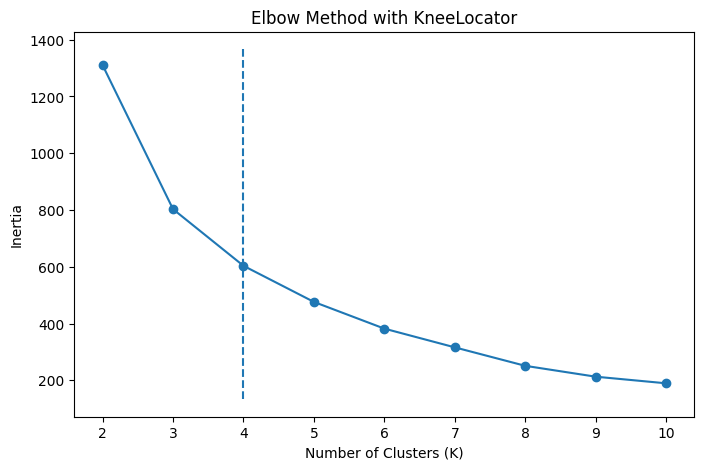

In [10]:
# =========================
# 5. FIND OPTIMAL K (KNEE LOCATOR)
# =========================

from kneed import KneeLocator

inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# =========================
# FIND ELBOW / KNEE POINT
# =========================

knee_locator = KneeLocator(
    K_range,
    inertia,
    curve='convex',
    direction='decreasing'
)

optimal_k = knee_locator.elbow

print("Optimal K:", optimal_k)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

# Highlight optimal K

plt.vlines(
    optimal_k,
    plt.ylim()[0],
    plt.ylim()[1],
    linestyles='dashed'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method with KneeLocator")

plt.show()

In [ ]:
# =========================
# 6. TRAIN FINAL MODEL
# =========================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

df["Cluster"] = clusters

In [12]:
# =========================
# 7. SILHOUETTE SCORE
# =========================

score = silhouette_score(rfm_scaled, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.4508


In [13]:

# =========================
# 8. CLUSTER SUMMARY
# =========================

cluster_summary = df.groupby("Cluster")[[
    "days_since_last_order",
    "total_orders",
    "total_revenue"
]].mean().round(2)

cluster_summary["customer_count"] = (
    df.groupby("Cluster")["customer_code"]
    .count()
)

print(cluster_summary)


         days_since_last_order  total_orders  total_revenue  customer_count
Cluster                                                                    
0                       426.44          1.61   5.039812e+07             274
1                        61.72          2.67   1.072105e+08             230
2                        69.39         10.50   4.707594e+08             142
3                        78.54          1.16   1.963578e+07             149


In [14]:
cluster_names = {
    0: "At Risk Customers",
    1: "Active Customers",
    2: "VIP Customers",
    3: "Low Value Customers"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

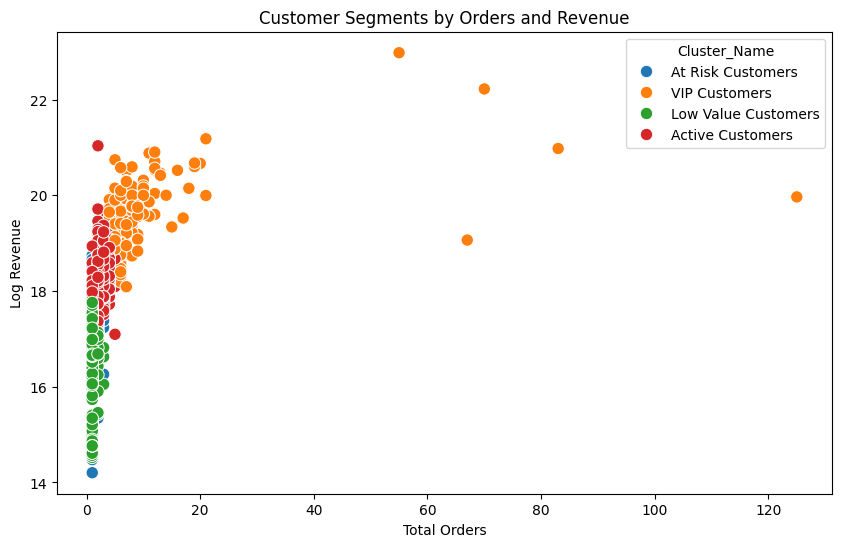

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="total_orders",
    y=np.log1p(df["total_revenue"]),
    hue="Cluster_Name",
    s=80
)

plt.title("Customer Segments by Orders and Revenue")

plt.xlabel("Total Orders")
plt.ylabel("Log Revenue")

plt.show()

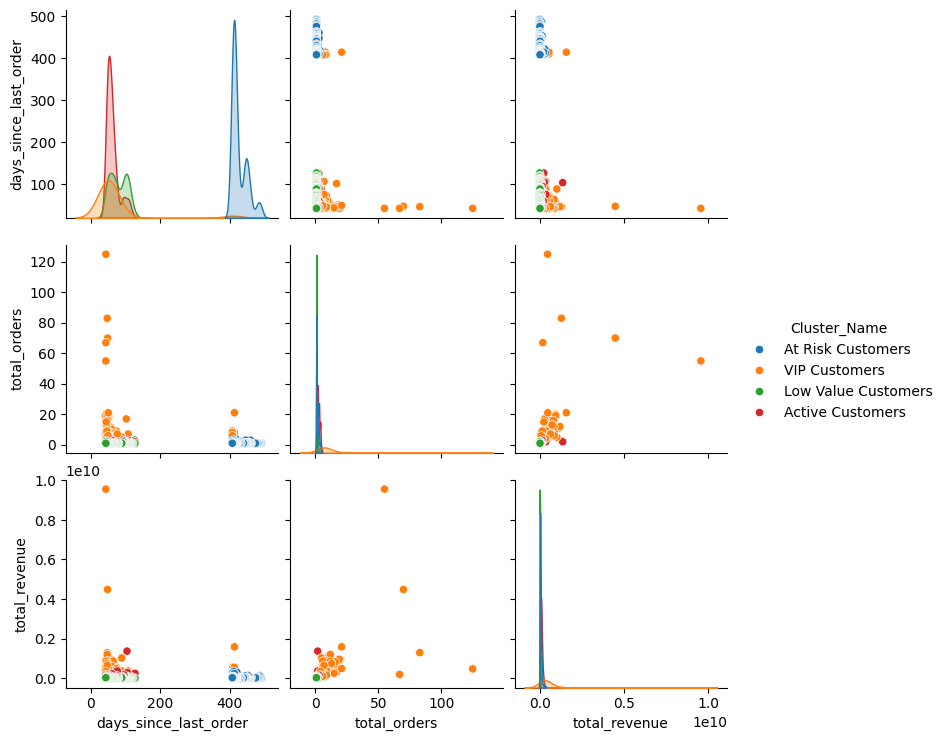

In [16]:
sns.pairplot(
    df[[
        "days_since_last_order",
        "total_orders",
        "total_revenue",
        "Cluster_Name"
    ]],
    hue="Cluster_Name"
)

plt.show()

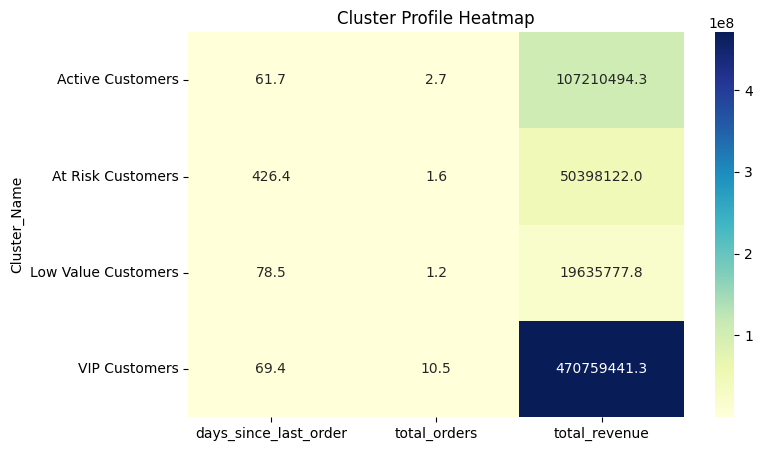

In [17]:
cluster_profile = df.groupby("Cluster_Name")[[
    "days_since_last_order",
    "total_orders",
    "total_revenue"
]].mean()

plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Cluster Profile Heatmap")

plt.show()

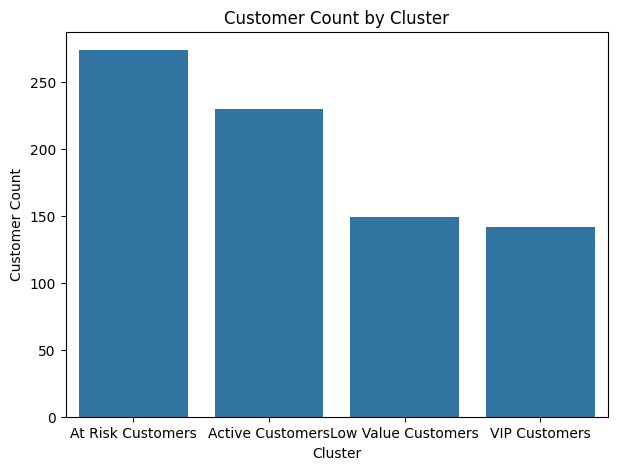

In [18]:
cluster_counts = (
    df["Cluster_Name"]
    .value_counts()
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Customer Count by Cluster")

plt.xlabel("Cluster")
plt.ylabel("Customer Count")

plt.show()

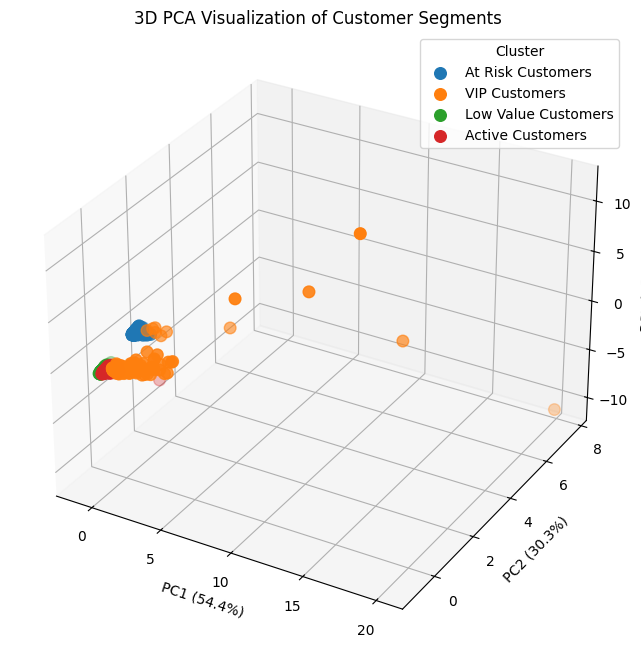

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Features dùng để clustering
features = [
    "days_since_last_order",
    "total_orders",
    "total_revenue"
]

# Scale dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# PCA 3 chiều
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# DataFrame PCA
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "Cluster_Name": df["Cluster_Name"]
})

# Plot 3D
fig = plt.figure(figsize=(11,8))

ax = fig.add_subplot(111, projection='3d')

# Vẽ từng cluster
for cluster in pca_df["Cluster_Name"].unique():

    subset = pca_df[pca_df["Cluster_Name"] == cluster]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=70,
        label=cluster
    )

ax.set_title("3D PCA Visualization of Customer Segments")

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

ax.set_zlabel(
    f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
)

ax.legend(title="Cluster")

plt.show()